# User Notebook

## Introduction

The library supports **data synthesis** based on target statistics. This notebook demonstrates how to define **custom loss functions** that compare statistical descriptors, and how to **run optimization procedures** to generate signals or fields that match desired statistical properties.

Examples are provided to illustrate typical workflows and recommended usage patterns.

Note:

- For **2D Kernel** data: **mean**, **variance**, **scattering coefficients**, and **power spectrum** can be computed (periodic or non-periodic data; with or without NaN values).

- For **2D FFT** data: **mean**, **variance**, **scattering coefficients**, and **power spectrum** can be computed (periodic or non-periodic data; NaN values are non handled).

In [9]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
import sys

from types import SimpleNamespace

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch, WaveletOperator2Dkernel_torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Working on device: cpu


In [10]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

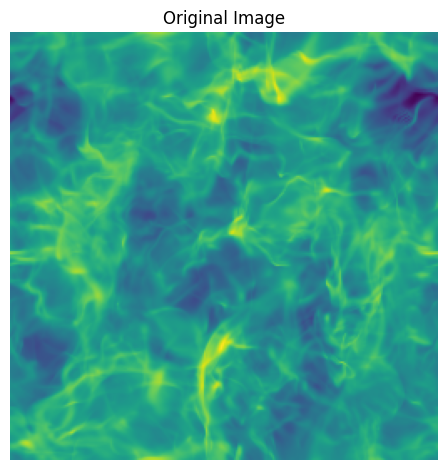

In [11]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]

# Visualize loaded data
plt.imshow(im[0, 0, :, :])
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## Synthesis

| Category | Input image(s) | Output image(s) | Channel(s) | Method(s) |
|----------|---------------|-----------------|---------|--------|
| One → One | 1 PBC image | 1 PBC image | Mono + Cross | Kernel + FFT |
| Many → One | N PBC images | 1 PBC image | Mono | Kernel + FFT |
| One → Many | 1 PBC image | N PBC images | Mono | Kernel + FFT |
| Many → Many | N PBC images | M PBC images | Mono | Kernel + FFT |
| PBC → Non PBC | 1 PBC image | 1 non-PBC image | Mono | Kernel + FFT |
| Non PBC → PBC | 1 non-PBC image | 1 PBC image | Mono | Kernel + FFT |
| Non PBC → Non PBC | 1 non-PBC image | 1 non-PBC image | Mono | Kernel + FFT |
| NaNs → NaNs | 1 image with NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → NaNs (≠ Mask)| 1 image with NaNs  | 1 image with NaNs | Mono | Kernel |
| Non NaNs → NaNs | 1 image without NaNs | 1 image with NaNs | Mono | Kernel |
| NaNs → Non NaNs | 1 image with NaNs | 1 image without NaNs | Mono | Kernel |


#### 1. One → One 

##### 1.1 Kernel - Mono

In [36]:
im_target = im[0, 0, :, :] # Mono channel image

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Get ST operator
st_op = data_target_kernel.get_ST_op()

# Run optimization
compute_cross_matrix = None # No cross-channel scattering coefficients to compute for mono-channel image
u1_kernel_mono, histo1 = optimize_scattering_LBFGS(
        target=data_target_kernel, 
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

Running synthesis on device cpu dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 2.014500e+02
[LBFGS] inner iter 20, loss = 1.190996e+01
[LBFGS] inner iter 30, loss = 1.070993e+00
[LBFGS] inner iter 40, loss = 5.254822e-01
[LBFGS] inner iter 50, loss = 3.548908e-01
58 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 43.176 s


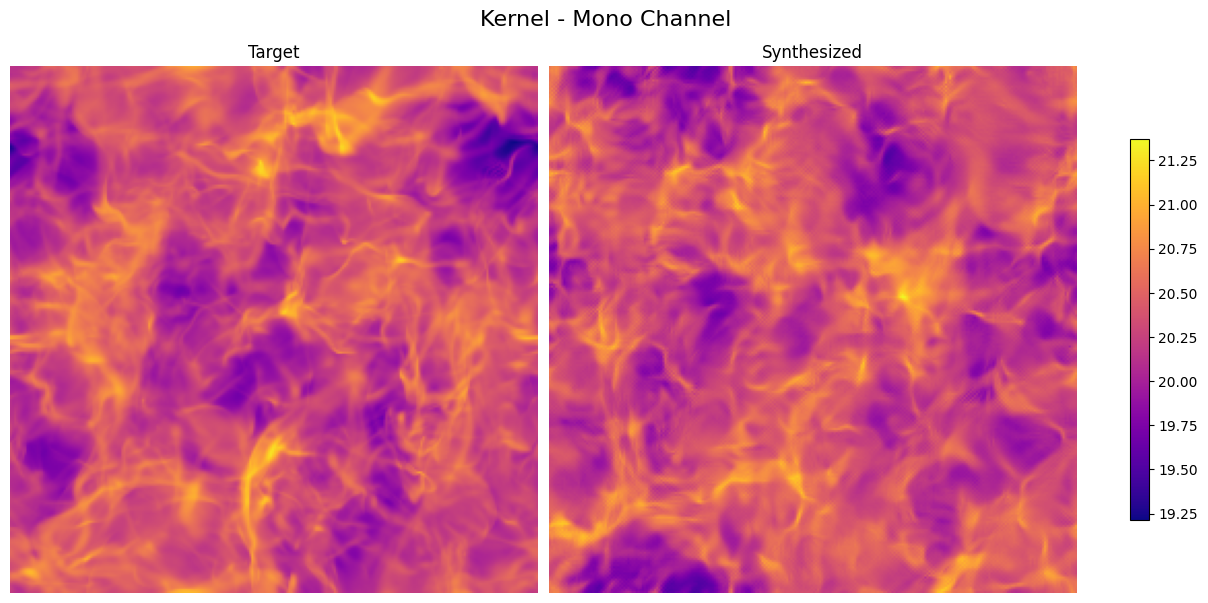

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

t = data_target_kernel.array.cpu().numpy()
u = u1_kernel_mono.cpu().numpy()

vmin = min(t.min(), u.min())
vmax = max(t.max(), u.max())

im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
axes[0].axis("off")
axes[0].set_title("Target")

im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].axis("off")
axes[1].set_title("Synthesized")

fig.colorbar(im0, ax=axes, shrink=0.7)

fig.suptitle("Kernel - Mono Channel", fontsize=16)

plt.show()

##### 1.2 FFT - Mono

In [51]:
im_target = im[0, 0, :, :] # Mono channel image

# Instantiate FFT data class on the target image
data_target_fft = STL_2D_FFT_Torch(im_target, pbc=True)

# Get ST operator
st_op = data_target_fft.get_ST_op()

# Run optimization
compute_cross_matrix = None # No cross-channel scattering coefficients to compute for mono-channel image
u1_fft_mono, histo1 = optimize_scattering_LBFGS(
        target=data_target_fft,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

Running synthesis on device cpu dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 1.148974e+02
[LBFGS] inner iter 20, loss = 2.621434e+00
[LBFGS] inner iter 30, loss = 1.942240e-01
[LBFGS] inner iter 40, loss = 1.100093e-01
[LBFGS] inner iter 50, loss = 3.983586e-02
[LBFGS] inner iter 60, loss = 2.112456e-02
60 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 33.582 s


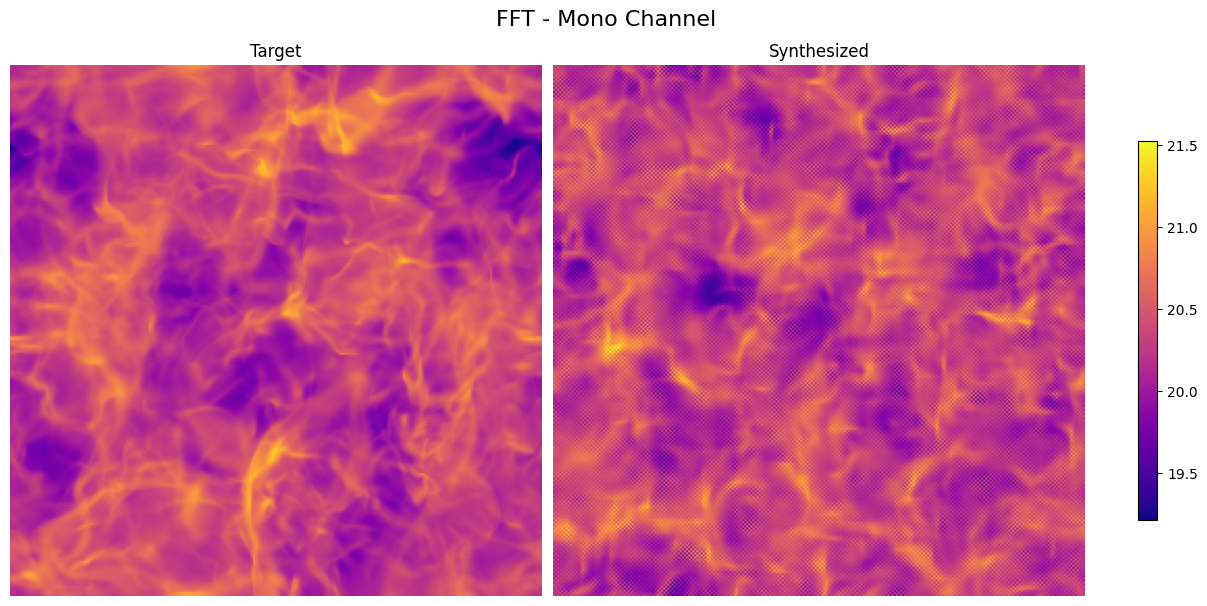

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

t = data_target_fft.array.cpu().numpy()
u = u1_fft_mono.cpu().numpy()

vmin = min(t.min(), u.min())
vmax = max(t.max(), u.max())

im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
axes[0].axis("off")
axes[0].set_title("Target")

im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].axis("off")
axes[1].set_title("Synthesized")

fig.colorbar(im0, ax=axes, shrink=0.7)

fig.suptitle("FFT - Mono Channel", fontsize=16)

plt.show()

##### 1.3 Kernel - Multi

In [ ]:
im_target = np.stack([im[0, 0, :, :], (im[0 ,0, :, :]-im[0, 0, :, :].mean(keepdims=True))**2])
im_target -= im_target.mean(axis=(1,2), keepdims=True)

# Instantiate kernel data class on the multi-channel target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Get ST operator
st_op = data_target_kernel.get_ST_op()

# Run optimization
compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool) # Specify compute_cross_matrix to compute cross-channel scattering coefficients
u1_kernel_multi, histo1 = optimize_scattering_LBFGS(
        target=data_target_kernel,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=4,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

Running synthesis on device cpu dtype torch.float64
Initial shape for u: (4, 2, 256, 256)
Synthesis on 15804 ST coefficients


KeyboardInterrupt: 

##### 1.4 FFT - Multi

In [ ]:
im_target = np.stack([im[0, 0, :, :], (im[0 ,0, :, :]-im[0, 0, :, :].mean(keepdims=True))**2])
im_target -= im_target.mean(axis=(1,2), keepdims=True)

# Instantiate FFT data class on the multi-channel target image
data_target_fft = STL_2D_FFT_Torch(im_target, pbc=True)

# Get ST operator
st_op = data_target_fft.get_ST_op()

# Run optimization
compute_cross_matrix = torch.tensor([[1, 1], [0, 1]], dtype=torch.bool) # Specify compute_cross_matrix to compute cross-channel scattering coefficients
u1_fft_multi, histo1 = optimize_scattering_LBFGS(
        target=data_target_fft,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=4,
        max_iter=50,
        lr=1.0,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=26,
    )

#### Many → One

#### One → Many

#### Many → Many

#### PBC → Non PBC

#### Non PBC → PBC

#### Non PBC → Non PBC

#### NaNs → NaNs

#### NaNs → NaNs (≠ Mask)

#### Non NaNs → NaNs

#### NaNs → Non NaNs